# **Lab 3**: Supervised Machine Learning
In this lab you will practice some supervised machine learning: 

- first training and testing a machine learning algorithm to classify hand-written digits; 
- second, using regression to calculate the relationship between a nation's population active on facebook and the number of Nobel prizes its citizens have been awarded.

You will also continue to practice programming in python, which I think we can all agree, is somewhat special.

To pass this lab you must complete all parts marked with a "*". You can do more parts, of course, because in the end that will help you on your project!

*HINT: See code that we have presented in class.*

# Part 1: Classification

# 1.1* 

The following code loads the digits dataset. Determine how many examples there are of each of the digits. Select one of the digits (for instance "8") and show two examples selected at random.


Number 0 appears 178 times
Number 1 appears 182 times
Number 2 appears 177 times
Number 3 appears 183 times
Number 4 appears 181 times
Number 5 appears 182 times
Number 6 appears 181 times
Number 7 appears 179 times
Number 8 appears 174 times
Number 9 appears 180 times


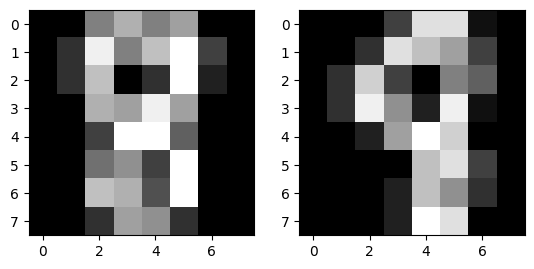

In [53]:
from sklearn import datasets
import numpy as np
%matplotlib inline 
import matplotlib.pyplot as plt
digits = datasets.load_digits()

data = digits.data
target = digits.target

# print(data)

res, counts = np.unique(target, return_counts=True)

for i in range(len(counts)):
    print(f"Number {res[i]} appears {counts[i]} times")

selected_number = 8

instances = np.where(target == selected_number)[0]

result = np.random.choice(instances, size=2, replace=False)

fig, ax = plt.subplots(1,2)
axes = 0
for i in result:
    ax[axes].imshow(data[i].reshape(8,8), cmap="gray")
    axes+=1
plt.show()
    


# 1.2* 

Using the appropriate sklearn routine, split the digits dataset into a  training set and a test set of the same size.

In [ ]:
# add your code below
from sklearn.model_selection import train_test_split
data_train, data_test, target_train, target_test = train_test_split(digits.data, digits.target, train_size=0.5, test_size=0.5)
print(data.shape, data_train.shape, data_test.shape, target_train.shape, target_test.shape)


(1797, 64) (898, 64) (899, 64) (898,) (899,)


# 1.3*

With your datasets, now train and test a kNN model for k in {1, 2, ..., 10}, and plot a figure showing the accuracy on the training set and on the test set as a function of k.

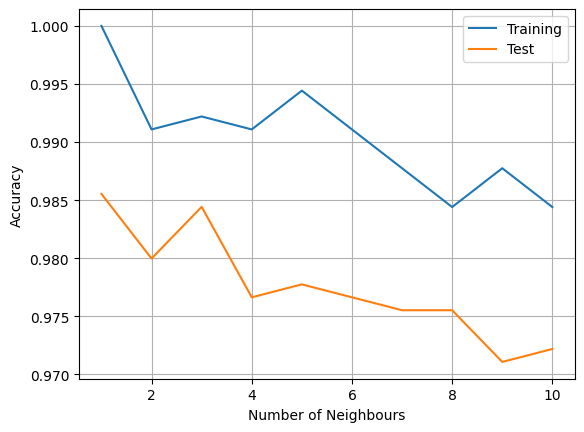

In [72]:
# add your code below

from sklearn.neighbors import KNeighborsClassifier
n_neighbors_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

acc_train = []
acc_test = []

for i in n_neighbors_list:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(data_train, target_train)
    acc_train.append(knn.score(data_train, target_train))
    acc_test.append(knn.score(data_test, target_test))

figfig, ax = plt.subplots()
plt.plot(n_neighbors_list,acc_train)
plt.plot(n_neighbors_list,acc_test)
plt.xlabel('Number of Neighbours')
plt.ylabel('Accuracy')
plt.legend(['Training','Test'])
plt.grid()
plt.show()




# 1.4*

Using your result from 1.3, which values of k can you observe overfitting? Which value of k is the best and why?

**Answer**: The best value for k is 3, and you can observe overfitting for k=7 since the test accuracy graph shows plateauing while the training declines. K=10 we can see that the test accuracy increases while the training decreases.

# 1.5* 

Train a kNN classifier with your best value of k, and display the confusion table of the training classifer applied to the testing dataset. (Hint: see part on confusion matrices in Chapter 5 of the course book.)

In [ ]:
from sklearn.metrics import confusion_matrix

def print_cm(cm, labels, hide_zeroes=False, hide_diagonal=False, hide_threshold=None):
    """pretty print for confusion matrixes"""
    """taken from https://gist.github.com/zachguo/10296432"""
    columnwidth = max([len(str(x)) for x in labels] + [5])  # 5 is value length
    empty_cell = " " * columnwidth
    
    # Begin CHANGES
    fst_empty_cell = (columnwidth-3)//2 * " " + "t\p" + (columnwidth-3)//2 * " "
    
    if len(fst_empty_cell) < len(empty_cell):
        fst_empty_cell = " " * (len(empty_cell) - len(fst_empty_cell)) + fst_empty_cell
    # Print header
    print("    " + fst_empty_cell, end=" ")
    # End CHANGES
    
    for label in labels:
        print("%{0}s".format(columnwidth) % label, end=" ")
        
    print()
    # Print rows
    for i, label1 in enumerate(labels):
        print("    %{0}s".format(columnwidth) % label1, end=" ")
        for j in range(len(labels)):
            cell = "%{0}.2f".format(columnwidth) % cm[i, j]
            if hide_zeroes:
                cell = cell if float(cm[i, j]) != 0 else empty_cell
            if hide_diagonal:
                cell = cell if i != j else empty_cell
            if hide_threshold:
                cell = cell if cm[i, j] > hide_threshold else empty_cell
            print(cell, end=" ")
        print()
        
# add your code below
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(data_train, target_train)
target_pred = knn.predict(data_test)
confusion = confusion_matrix(target_test, target_pred)
print_cm(confusion, digits.target_names)


     t\p      0     1     2     3     4     5     6     7     8     9 
        0 95.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
        1  0.00 93.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
        2  0.00  0.00 90.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
        3  0.00  0.00  1.00 91.00  0.00  1.00  0.00  1.00  0.00  0.00 
        4  0.00  1.00  0.00  0.00 86.00  0.00  0.00  0.00  0.00  1.00 
        5  0.00  0.00  0.00  0.00  0.00 100.00  0.00  0.00  0.00  0.00 
        6  0.00  0.00  0.00  0.00  0.00  0.00 84.00  0.00  0.00  0.00 
        7  0.00  0.00  0.00  0.00  0.00  0.00  0.00 92.00  0.00  1.00 
        8  0.00  3.00  0.00  2.00  0.00  0.00  0.00  0.00 73.00  0.00 
        9  0.00  0.00  0.00  0.00  0.00  2.00  0.00  0.00  1.00 81.00 


<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Adam\AppData\Local\Temp\ipykernel_7412\486535819.py:10: SyntaxWarning: invalid escape sequence '\p'
  fst_empty_cell = (columnwidth-3)//2 * " " + "t\p" + (columnwidth-3)//2 * " "


# 1.6*

From your confusion table:
- which two digits are confused the most? Try to explain why.
- which digit(s) is(are) the hardest to identify? Try to explain why.
- which digit(s) is(are) the easiest to identify? Try to explain why.

**Answer**: The two numbers that get the most confused are 1 and 8 since we can see in the matrix that the training predicted 3 eights were ones. The hardest number to predict is 8, since that is the number the training predicted wrong the most, which can be found be looking at the rows of the true value and adding up the non-correctly predicted numbers. The easiest, using the same method but looking at the lowest numbers, would be 0, 1, 2, 5, 6 since all of them had 0 wrongly predicted.


# 1.7 

Using the dataset split from 1.2, train and test a different classifer, and create a confusion table. 

In [0]:
# add your code below

# 1.8

Compare the confusion tables in 1.7 and 1.5. Was there an improvement anywhere? Was there a deterioration?

**Answer**:

# Part 2: Regression

# 2.1* 

Load the dataset "SweetFaceNobel.txt". The columns of this dataset mean the following: Name of country, number of nobel prizes awarded to citizens of that country, the population of that country, per capita consumption of chocholate in that country (kg), and the number of citizens of that country that have a facebook account. Make a scatter plot of the per capita Nobel Prizes versus the percentage of facebook users of a country.


<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Adam\AppData\Local\Temp\ipykernel_7412\1440920502.py:3: SyntaxWarning: invalid escape sequence '\l'
  with open("datasets\lab_3\SweetFaceNobel-2.txt", "r") as data:


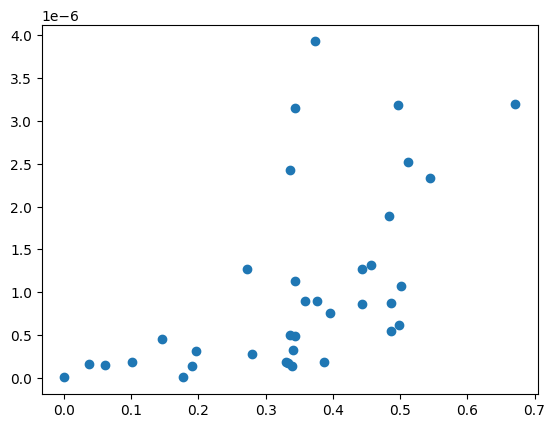

In [108]:
# add your code below 
from csv import DictReader
with open("datasets\lab_3\SweetFaceNobel-2.txt", "r") as data:
    dict_reader = DictReader(data)
    sfn = list(dict_reader)

proc_fb = []
pc_nobel = []

for i in range(len(sfn)):
    proc_fb.append(int(sfn[i]["FB"])/int(sfn[i]["POP"]))
    pc_nobel.append(int(sfn[i]["NOBEL"])/int(sfn[i]["POP"]))

plt.scatter(proc_fb,pc_nobel)
plt.show()

# 2.2* 

Find the parameters of the line $y = mx + b$ fit to this data by the method of least squares, where $x$ is the percentage of people on fb, and $y$ is the per capita number of Nobel prizes.


In [112]:
# add your code below
from numpy.linalg import lstsq
A = np.vstack([proc_fb, np.ones(len(proc_fb))]).T
coefficients1, residuals, rank ,s = lstsq(A, pc_nobel)
print(coefficients1)


[ 3.94812778e-06 -3.10595569e-07]


# 2.3* 

According to your model:
- For a country with a population of 10 million, how many more Nobel prizes should it expect to win if the percentage of that country on facebook increases 10 percentage points?
- What is the maximum percentage of facebook users of a country where the number of Nobel prizes is negative?

**Answer**: With the values provided by the lstsq method, an increase of 10% in facebook users would result in 4 more nobel prices. The maximum procentage would be around 8%


# 2.4* 

Find the parameters of the model $y = m_1x^2 + m_2x + b$ fit to this data by the method of least squares.


[5.40108197e-06 6.03167293e-07 7.73170582e-08]


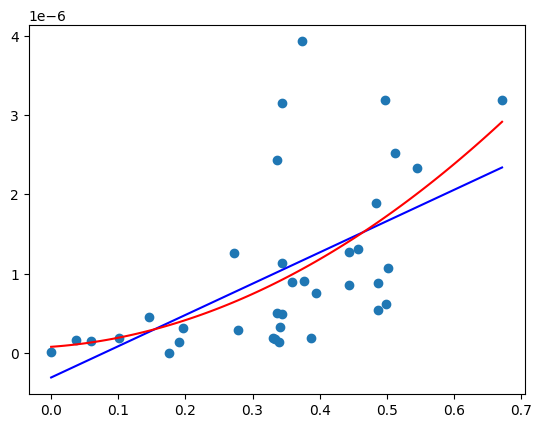

In [115]:
# add your code below
coefficients2 = np.polyfit(proc_fb, pc_nobel, 2)
print(coefficients2)

x = np.array(proc_fb)
y = np.array(pc_nobel)

plt.scatter(proc_fb,pc_nobel)
p =  np.poly1d(coefficients2)

x1_line = np.linspace(min(x), max(x), 100)
y1_line = coefficients1[0]*x1_line+coefficients1[1]

y2_line = coefficients2[0]*(x1_line*x1_line)+coefficients2[1]*x1_line+coefficients2[2]

plt.plot(x1_line,y1_line, color="blue")
plt.plot(x1_line,y2_line, color="red")

plt.show()

# 2.5* 

Explain: 
- Which of the two models you fit to the data makes the most sense, i.e., the model in 2.3 and the model in 2.4.
- How you would respond to the claim that increasing facebook activity in a country increases its scientific excellence?

**Answer**: The second method fits better, which can be seen in the plots in 2.4. There would be no correlation between the increase in facebook activity and an increase in nobel prices, the fact that they have any form of correlation is just a coincidence.


# 2.6

Find the parameters of the least squares plane ($y = m_1x + m_2z + b$) fit to this data, where $x$ is the percentage of facebook users of a country, and $z$ is the chocolate consumption per capita.


In [0]:
# add your code below


# 2.7

Find the parameters of the least squares surface ($y = m_1x + m_2x^2 + m_3z + m_4xz + b$) fit to this data, where $x$ is the percentage of facebook users of a country, and $z$ is the chocolate consumption per capita.


In [0]:
# add your code below
